In [1]:
import tensorflow as tf
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))


GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np
print(np.__version__)

1.26.4


In [15]:
import pandas as pd
import polars as pl

df = pl.read_csv("basefinal.csv")
df_pd = df.to_pandas()  # 4563 por espectro

In [22]:
import pandas as pd
import polars as pl

df = pl.read_csv("espectros_final_4563.csv")
df_pd = df.to_pandas() 

In [23]:
conteo_por_id = df_pd['SDSS_ID'].value_counts().sort_index()

# Mostrar algunos ejemplos
print(conteo_por_id.head())  # los primeros 5
print(f"\nPromedio de observaciones por espectro: {conteo_por_id.mean():.2f}")
print(f"Máximo: {conteo_por_id.max()}, Mínimo: {conteo_por_id.min()}")


SDSS_ID
spec-0266-51630-0543    4563
spec-0267-51608-0091    4563
spec-0267-51608-0292    4563
spec-0268-51633-0477    4563
spec-0269-51910-0512    4563
Name: count, dtype: int64

Promedio de observaciones por espectro: 4563.00
Máximo: 4563, Mínimo: 4563


In [24]:
for id, grupo in df_pd.groupby('SDSS_ID'):
    em = grupo['emision'].values
    absb = grupo['absorcion'].values

    total_emisiones = em.sum()
    total_absorciones = absb.sum()

    print(f"ID: {id} | Emisiones: {total_emisiones} | Absorciones: {total_absorciones}")


ID: spec-0266-51630-0543 | Emisiones: 15 | Absorciones: 11
ID: spec-0267-51608-0091 | Emisiones: 14 | Absorciones: 10
ID: spec-0267-51608-0292 | Emisiones: 16 | Absorciones: 6
ID: spec-0268-51633-0477 | Emisiones: 11 | Absorciones: 10
ID: spec-0269-51910-0512 | Emisiones: 12 | Absorciones: 10
ID: spec-0269-51910-0605 | Emisiones: 15 | Absorciones: 9
ID: spec-0270-51909-0216 | Emisiones: 13 | Absorciones: 9
ID: spec-0271-51883-0007 | Emisiones: 14 | Absorciones: 9
ID: spec-0271-51883-0049 | Emisiones: 13 | Absorciones: 11
ID: spec-0271-51883-0177 | Emisiones: 12 | Absorciones: 10
ID: spec-0271-51883-0555 | Emisiones: 13 | Absorciones: 10
ID: spec-0271-51883-0593 | Emisiones: 10 | Absorciones: 11
ID: spec-0272-51941-0034 | Emisiones: 13 | Absorciones: 11
ID: spec-0272-51941-0271 | Emisiones: 11 | Absorciones: 11
ID: spec-0272-51941-0304 | Emisiones: 13 | Absorciones: 10
ID: spec-0273-51957-0116 | Emisiones: 12 | Absorciones: 11
ID: spec-0273-51957-0343 | Emisiones: 14 | Absorciones: 10
I

In [14]:
total_emisiones = df_pd['emision'].sum()
total_absorciones = df_pd['absorcion'].sum()

print(f"Total global → Emisiones: {total_emisiones} | Absorciones: {total_absorciones}")


Total global → Emisiones: 0 | Absorciones: 0


In [ ]:
import numpy as np
ids_muestra = np.random.choice(df_pd['ID'].unique(), size=6000, replace=False)
df_filtrado = df_pd[df_pd['ID'].isin(ids_muestra)]


In [ ]:
df_pd = df_filtrado

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np
X = []
y = []

for _, grupo in df_pd.groupby('ID'):
    flujo = grupo['flux'].values
    onda = grupo['wave'].values
    em = grupo['em_peak'].values
    absb = grupo['abs_peak'].values
    for i in range(0, len(flujo) - 27, 27):
        ventana_flujo = flujo[i:i+27]
        ventana_onda = onda[i:i+27]
        etiqueta = 0
        if em[i:i+27].sum() > 0:
            etiqueta = 1
        elif absb[i:i+27].sum() > 0:
            etiqueta = -1
        ventana = np.stack([ventana_flujo, ventana_onda], axis=-1)
        X.append(ventana)
        y.append(etiqueta)

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np

X = []
y = []

for _, grupo in df_pd.groupby('ID'):
    flujo = grupo['flux'].values
    onda = grupo['wave'].values
    em = grupo['em_peak'].values  # Binario: 1 si hay emisión en ese punto
    absb = grupo['abs_peak'].values  # Binario: 1 si hay absorción en ese punto

    # Estandarización por espectro (puntaje Z)
    flujo_mean = flujo.mean()
    flujo_std = flujo.std()
    flujo = (flujo - flujo_mean) / (flujo_std + 1e-8)

    onda_mean = onda.mean()
    onda_std = onda.std()
    onda = (onda - onda_mean) / (onda_std + 1e-8)

    for i in range(0, len(flujo) - 27 + 1, 1):  # sliding window de tamaño 27, paso 1
        ventana_flujo = flujo[i:i+27]
        ventana_onda = onda[i:i+27]

        ventana = np.stack([ventana_flujo, ventana_onda], axis=-1)  # (27, 2)
        X.append(ventana)

        ventana_em = em[i:i+27]
        ventana_absb = absb[i:i+27]

        ventana_etiquetas = []
        for j in range(27):
            if ventana_em[j] == 1:
                etiqueta = [1, 0, 0]  # emisión
            elif ventana_absb[j] == 1:
                etiqueta = [0, 1, 0]  # absorción
            else:
                etiqueta = [0, 0, 1]  # nada
            ventana_etiquetas.append(etiqueta)

        y.append(ventana_etiquetas)  # (27, 3)

# Convertir a arrays
X = np.array(X)  # (n_muestras, 27, 2)
y = np.array(y)  # (n_muestras, 27, 3)


In [ ]:
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np

X = []
y = []

for _, grupo in df_pd.groupby('ID'):
    flujo = grupo['flux'].values
    onda = grupo['wave'].values
    em = grupo['em_peak'].values  # Binario: 1 si hay emisión en ese punto
    absb = grupo['abs_peak'].values  # Binario: 1 si hay absorción en ese punto

    # Estandarización por espectro (puntaje Z)
    flujo_mean = flujo.mean()
    flujo_std = flujo.std()
    flujo = (flujo - flujo_mean) / (flujo_std + 1e-8)

    onda_mean = onda.mean()
    onda_std = onda.std()
    onda = (onda - onda_mean) / (onda_std + 1e-8)

    for i in range(0,len(flujo) - 27, 27):  # sliding window de tamaño 27, paso 1
        ventana_flujo = flujo[i:i+27]
        ventana_onda = onda[i:i+27]

        ventana = np.stack([ventana_flujo, ventana_onda], axis=-1)  # (27, 2)
        X.append(ventana)

        ventana_em = em[i:i+27]
        ventana_absb = absb[i:i+27]

        ventana_etiquetas = []
        for j in range(27):
            if ventana_em[j] == 1:
                etiqueta = [1, 0, 0]  # emisión
            elif ventana_absb[j] == 1:
                etiqueta = [0, 1, 0]  # absorción
            else:
                etiqueta = [0, 0, 1]  # nada
            ventana_etiquetas.append(etiqueta)

        y.append(ventana_etiquetas)  # (27, 3)

# Convertir a arrays
X = np.array(X)  # (n_muestras, 27, 2)
y = np.array(y)  # (n_muestras, 27, 3)


In [3]:
X

array([], dtype=float64)

In [25]:
# ESTANDARIZAR POR EL FLUX
from numpy.lib.stride_tricks import sliding_window_view
import numpy as np

X = []
y = []

for _, grupo in df_pd.groupby('SDSS_ID'):
    flujo = grupo['flux'].values
    onda = grupo['wavelength'].values
    em = grupo['emision'].values
    absb = grupo['absorcion'].values

    # Estandarización por espectro (puntaje Z)
    flujo_mean = flujo.mean()
    flujo_std = flujo.std()
    flujo = (flujo - flujo_mean) / (flujo_std + 1e-8)

    onda_mean = onda.mean()
    onda_std = onda.std()
    onda = (onda -  onda_mean) / (onda_std + 1e-8)

    for i in range(0, len(flujo) - 27, 27):
        ventana_flujo = flujo[i:i+27]
        ventana_onda = onda[i:i+27]
        etiqueta = 0
        if em[i:i+27].sum() > 0:
            etiqueta = 1
        elif absb[i:i+27].sum() > 0:
            etiqueta = -1
        ventana = np.stack([ventana_flujo, ventana_onda], axis=-1)
        X.append(ventana)
        y.append(etiqueta)


In [12]:
em = grupo['emision'].values.sum
print(em)

<built-in method sum of numpy.ndarray object at 0x0000020D5528C030>


In [26]:
import numpy as np

# Convertir listas a arrays finales
X = np.array(X)        # (n_ventanas, 27, 2)
y = np.array(y)        # (n_ventanas,)


In [18]:
import numpy as np

# Paso 1: obtener los índices por clase
idx_em = np.where(y == 1)[0]
idx_abs = np.where(y == -1)[0]
idx_nada = np.where(y == 0)[0]

# Paso 2: seleccionar 600,000 aleatorios de 'nada'
np.random.seed(42)  # reproducibilidad
idx_nada_sel = np.random.choice(idx_nada, size=600_000, replace=False)

# Paso 3: combinar todos los índices
idx_finales = np.concatenate([idx_em, idx_abs, idx_nada_sel])

# Paso 4: filtrar los arrays
X = X[idx_finales]
y = y[idx_finales]


In [27]:
import numpy as np

valores, conteos = np.unique(y, return_counts=True)
for v, c in zip(valores, conteos):
    tipo = {1: 'Emisión', -1: 'Absorción', 0: 'Nada'}.get(v, 'Desconocido')
    print(f"{tipo}: {c} ventanas")


Absorción: 25945 ventanas
Nada: 440438 ventanas
Emisión: 36777 ventanas


In [ ]:
print(df_pd)

In [8]:
y

array([0, 0, 0, ..., 0, 0, 0])

In [21]:
y[0]

1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Suponiendo que X tiene shape (n_ventanas, 9, 1)
# y tiene solo flujo en la columna 0 (porque no hay wave)
for i in range(3):
    ventana = X[i]           # shape (9, 1)
    flux = ventana[:, 0]     # columna 0: flujo
    etiqueta = y[i]          # etiqueta para la ventana

    plt.figure(figsize=(6, 3))
    plt.plot(range(len(flux)), flux, marker='o')
    plt.title(f"Ventana {i} - Etiqueta: {etiqueta}")
    plt.xlabel("Punto espectral (índice)")
    plt.ylabel("Flujo (flux)")
    plt.grid(True)
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definir cuál es el código para "absorción"
# Aquí asumo que absorción == -1, ajusta según corresponda
absorption_label = -1

# Filtrar índices de ventanas con absorción
indices_abs = [i for i, label in enumerate(y) if label == absorption_label]

# Para no saturar, graficar solo las primeras 3 ventanas con absorción
for count, i in enumerate(indices_abs[:10]):
    ventana = X[i]          # shape (9, 1)
    flux = ventana[:, 0]    # tomar la columna de flujo
    etiqueta = y[i]

    plt.figure(figsize=(6, 3))
    plt.plot(range(len(flux)), flux, marker='o')
    plt.title(f"Ventana {i} - Etiqueta: {etiqueta} (absorción)")
    plt.xlabel("Punto espectral (índice)")
    plt.ylabel("Flujo (flux)")
    plt.grid(True)
    plt.show()


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, GlobalAveragePooling1D,
                                     Dense, Dropout, BatchNormalization, LeakyReLU)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

# --- 1. Preparar etiquetas: convertir de -1,0,1 a 0,1,2 ---
y_mod = np.where(y == -1, 0, np.where(y == 0, 1, 2))

# --- 2. Dividir en train y test ---
# --- 2. Dividir en train y test ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_mod, test_size=0.2, random_state=42, stratify=y_mod
)

# --- 💡 AQUÍ VA LA LIMPIEZA ---
# Limpiar NaNs en X_train
mask_train = ~np.isnan(X_train).any(axis=(1, 2))
X_train = X_train[mask_train]
y_train_raw = y_train_raw[mask_train]

# Limpiar NaNs en X_test
mask_test = ~np.isnan(X_test).any(axis=(1, 2))
X_test = X_test[mask_test]
y_test_raw = y_test_raw[mask_test]

# --- 3. One-hot encoding para y_train y y_test ---
y_train = to_categorical(y_train_raw, num_classes=3)
y_test = to_categorical(y_test_raw, num_classes=3)

# --- 4. Calcular pesos de clase (sobre etiquetas planas) ---
y_train_flat = np.argmax(y_train, axis=1)
pesos = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=y_train_flat)
class_weight_dict = {i: pesos[i] for i in range(3)}
print("Pesos de clase:", class_weight_dict)


Pesos de clase: {0: 6.46444401618809, 1: 0.3808031786575848, 2: 4.5603969818503165}


In [37]:
X[0]

array([[-1.14772678, -1.73167126],
       [-0.73438126, -1.73091209],
       [-0.62984895, -1.73015292],
       [-1.1192237 , -1.72939375],
       [-1.71246157, -1.72863458],
       [-2.2339167 , -1.7278754 ],
       [-2.51835458, -1.72711623],
       [-2.61999208, -1.72635706],
       [-2.56897233, -1.72559789],
       [-2.5693686 , -1.72483872],
       [-2.67660685, -1.72407954],
       [-2.33146114, -1.72332037],
       [-2.22774415, -1.7225612 ],
       [-2.03798897, -1.72180203],
       [-2.31226193, -1.72104286],
       [-2.33974721, -1.72028368],
       [-2.41236825, -1.71952451],
       [-2.50703551, -1.71876534],
       [-2.6226347 , -1.71800617],
       [-2.71223919, -1.717247  ],
       [-2.73281279, -1.71648782],
       [-2.5868753 , -1.71572865],
       [-2.43100189, -1.71496948],
       [-2.14582497, -1.71421031],
       [-2.3318236 , -1.71345114],
       [-2.07419791, -1.71269196],
       [-2.11264192, -1.71193279]])

In [38]:
y[0]

0

In [29]:

# --- 5. Definir y compilar modelo ---

model = Sequential([
    Conv1D(256, kernel_size=5, padding='same', kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4),
           input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling1D(pool_size=2),

    Conv1D(512, kernel_size=3, padding='same', kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    LeakyReLU(),
    MaxPooling1D(pool_size=2),

    Conv1D(1024, kernel_size=3, padding='same', kernel_initializer=HeNormal(), kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    LeakyReLU(),

    GlobalAveragePooling1D(),

    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1024, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])


model.compile(optimizer=Adam(learning_rate=3e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_6 (Conv1D)           (None, 27, 256)           2816      
                                                                 
 batch_normalization_6 (Batc  (None, 27, 256)          1024      
 hNormalization)                                                 
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 27, 256)           0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 13, 256)          0         
 )                                                               
                                                                 
 conv1d_7 (Conv1D)           (None, 13, 512)           393728    
                                                                 
 batch_normalization_7 (Batc  (None, 13, 512)         

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Bidirectional, LSTM, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.regularizers import l2

modelo_robusto = Sequential([
    # --- Extracción local de patrones con conv ---
    Conv1D(128, kernel_size=3, padding='same', kernel_regularizer=l2(1e-4),
           input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    LeakyReLU(),

    Conv1D(256, kernel_size=3, padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    LeakyReLU(),

    # --- LSTM bidireccional para patrones secuenciales ---
    Bidirectional(LSTM(128, return_sequences=False, dropout=0.2)),

    # --- Denso profundo ---
    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    # --- Salida ---
    Dense(3, activation='softmax')
])
modelo_robusto.summary()
modelo_robusto.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_4 (Conv1D)           (None, 27, 128)           896       
                                                                 
 batch_normalization_4 (Batc  (None, 27, 128)          512       
 hNormalization)                                                 
                                                                 
 leaky_re_lu_4 (LeakyReLU)   (None, 27, 128)           0         
                                                                 
 conv1d_5 (Conv1D)           (None, 27, 256)           98560     
                                                                 
 batch_normalization_5 (Batc  (None, 27, 256)          1024      
 hNormalization)                                                 
                                                                 
 leaky_re_lu_5 (LeakyReLU)   (None, 27, 256)          

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

modelo_lstm = Sequential([
    Bidirectional(LSTM(128, return_sequences=True),
                   input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

modelo_lstm.compile(optimizer=Adam(1e-4), 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])
modelo_lstm.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_3 (Bidirectio  (None, 27, 256)          134144    
 nal)                                                            
                                                                 
 dropout_10 (Dropout)        (None, 27, 256)           0         
                                                                 
 bidirectional_4 (Bidirectio  (None, 128)              164352    
 nal)                                                            
                                                                 
 dropout_11 (Dropout)        (None, 128)               0         
                                                                 
 dense_14 (Dense)            (None, 64)                8256      
                                                                 
 dropout_12 (Dropout)        (None, 64)               

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense, Dropout, BatchNormalization, LeakyReLU

modelo_cnn_gru = Sequential([
    Conv1D(128, kernel_size=3, padding='same', 
           input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    LeakyReLU(),

    Conv1D(256, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(),

    GRU(128, return_sequences=False, dropout=0.2),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

modelo_cnn_gru.compile(optimizer=Adam(1e-4), 
                       loss='categorical_crossentropy',
                         metrics=['accuracy'])

modelo_cnn_gru.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 27, 128)           896       
                                                                 
 batch_normalization (BatchN  (None, 27, 128)          512       
 ormalization)                                                   
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 27, 128)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 27, 256)           98560     
                                                                 
 batch_normalization_1 (Batc  (None, 27, 256)          1024      
 hNormalization)                                                 
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 27, 256)           0

In [37]:
from tensorflow.keras.optimizers import Adam
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_GRU.h5',       # Archivo a guardar
    monitor='val_accuracy',           # Puedes usar 'val_loss' también
    save_best_only=True,              # Solo guarda si mejora
    save_weights_only=False,          # Guarda arquitectura + pesos
    verbose=1                         # Imprime cuando guarda
)
history_gru = modelo_cnn_gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint]            # Agregado aquí
) # se tardo 46m y 23.6s

Epoch 1/10
1059/1059 [==============================] - ETA: 0s - loss: 0.8059 - accuracy: 0.5509
Epoch 1: val_accuracy improved from -inf to 0.55384, saving model to mejor_modelo_GRU.h5
1059/1059 [==============================] - 20s 15ms/step - loss: 0.8059 - accuracy: 0.5509 - val_loss: 0.7825 - val_accuracy: 0.5538
Epoch 2/10
1059/1059 [==============================] - ETA: 0s - loss: 0.7206 - accuracy: 0.5624
Epoch 2: val_accuracy improved from 0.55384 to 0.57439, saving model to mejor_modelo_GRU.h5
1059/1059 [==============================] - 16s 15ms/step - loss: 0.7206 - accuracy: 0.5624 - val_loss: 0.7834 - val_accuracy: 0.5744
Epoch 3/10
1057/1059 [============================>.] - ETA: 0s - loss: 0.6987 - accuracy: 0.5646
Epoch 3: val_accuracy did not improve from 0.57439
1059/1059 [==============================] - 16s 15ms/step - loss: 0.6987 - accuracy: 0.5647 - val_loss: 0.7637 - val_accuracy: 0.5720
Epoch 4/10
1059/1059 [==============================] - ETA: 0s - los

2647/2647 [==============================] - 11s 4ms/step


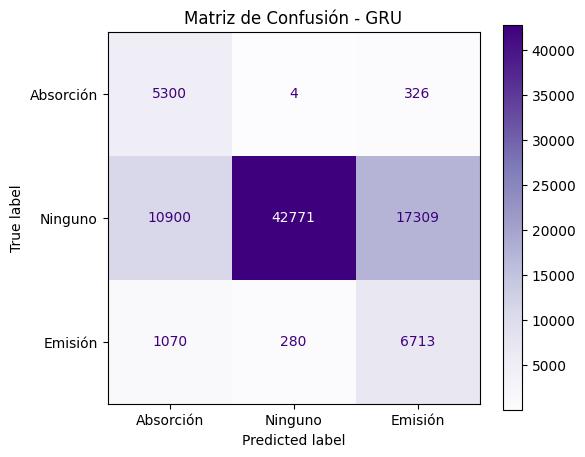

In [38]:
mejor_modelo_GRU = load_model('mejor_modelo_GRU.h5')

y_pred = mejor_modelo_GRU.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absorción', 'Ninguno', 'Emisión'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusión - GRU")
plt.show() 

3145/3145 [==============================] - 8s 2ms/step


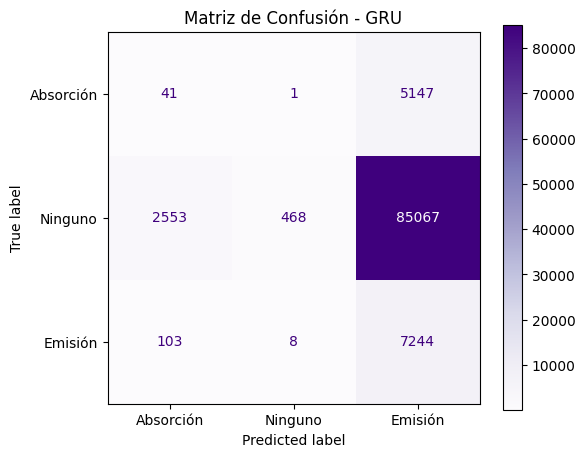

In [46]:
mejor_modelo = load_model('mejor_modelo.h5')

y_pred = mejor_modelo.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absorción', 'Ninguno', 'Emisión'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusión - GRU")
plt.show()

In [7]:
mejor_modelo_GRU = load_model('mejor_modelo_GRU.h5')
print(X_test)
y_pred = mejor_modelo_GRU.predict(X_test)

[[[ 0.90091698 -0.99000618]
  [ 0.9606974  -0.98946801]
  [ 1.00897234 -0.98892971]
  ...
  [ 0.50516432 -0.97705573]
  [ 0.43385103 -0.97651457]
  [ 0.39055769 -0.97597329]]

 [[ 1.31389357  1.19007757]
  [ 1.31987113  1.19111778]
  [ 1.31232008  1.19215824]
  ...
  [ 1.33792152  1.21510896]
  [ 1.34052137  1.21615494]
  [ 1.32735278  1.21720116]]

 [[ 0.03822918  0.49206941]
  [ 0.04052162  0.49294888]
  [ 0.04296202  0.49382856]
  ...
  [-0.00743452  0.51323279]
  [-0.00916918  0.51411714]
  [-0.01658712  0.51500169]]

 ...

 [[ 0.80345596 -0.38557651]
  [ 0.8322769  -0.38489914]
  [ 0.85940052 -0.38422162]
  ...
  [ 0.89274933 -0.3692766 ]
  [ 0.88436482 -0.36859548]
  [ 0.87946059 -0.36791421]]

 [[ 0.92965398  1.45002537]
  [ 0.91736818  1.45112545]
  [ 0.89952277  1.45222578]
  ...
  [ 0.93302158  1.47649726]
  [ 0.93155831  1.47760344]
  [ 0.95451913  1.47870986]]

 [[ 0.10474425 -1.3996634 ]
  [ 0.13042771 -1.39921956]
  [ 0.13867641 -1.39877562]
  ...
  [-0.03822327 -1.388983

In [9]:
print(y_pred)
print(y_test)

[[1.5108504e-05 2.2913931e-02 9.7707099e-01]
 [9.3006069e-04 9.9839109e-01 6.7890325e-04]
 [2.9447535e-04 9.9970019e-01 5.4020957e-06]
 ...
 [6.6720982e-06 9.9714273e-01 2.8506401e-03]
 [1.9479252e-04 9.9223375e-01 7.5714462e-03]
 [9.9980086e-01 1.9156479e-04 7.6358410e-06]]
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 ...
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


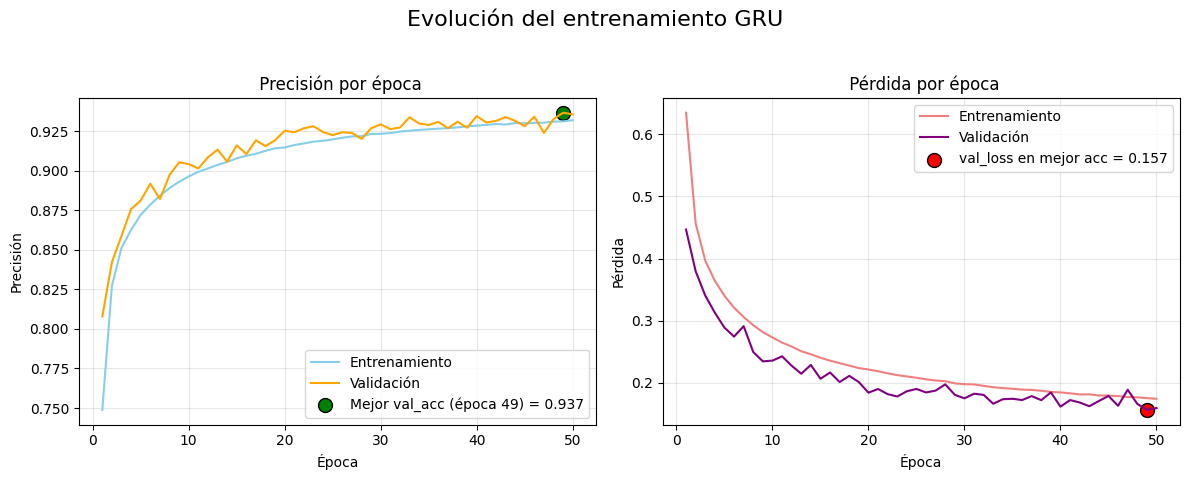

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ajustar mejor época para mostrarla desde 1 ---
mejor_epoca = np.argmax(history_gru.history['val_accuracy'])
mejor_epoca_mostrar = mejor_epoca + 1  # para humanos
mejor_acc = history_gru.history['val_accuracy'][mejor_epoca]
mejor_loss = history_gru.history['val_loss'][mejor_epoca]

# --- Crear vector de épocas desde 1 ---
epocas = np.arange(1, len(history_gru.history['val_accuracy']) + 1)

# --- Gráficos ---
plt.figure(figsize=(12, 5))

# 🎯 Precisión
plt.subplot(1, 2, 1)
plt.plot(epocas, history_gru.history['accuracy'], label='Entrenamiento', color='skyblue')
plt.plot(epocas, history_gru.history['val_accuracy'], label='Validación', color='orange')
plt.scatter(mejor_epoca_mostrar, mejor_acc, color='green', s=100, marker='o', edgecolors='black',
            label=f'Mejor val_acc (época {mejor_epoca_mostrar}) = {mejor_acc:.3f}')
plt.title(' Precisión por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(alpha=0.3)

# 📉 Pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, history_gru.history['loss'], label='Entrenamiento', color='lightcoral')
plt.plot(epocas, history_gru.history['val_loss'], label='Validación', color='purple')
plt.scatter(mejor_epoca_mostrar, mejor_loss, color='red', s=100, marker='o', edgecolors='black',
            label=f'val_loss en mejor acc = {mejor_loss:.3f}')
plt.title(' Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle("Evolución del entrenamiento GRU", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
from tensorflow.keras.optimizers import Adam
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_LSTM.h5',       # Archivo a guardar
    monitor='val_accuracy',           # Puedes usar 'val_loss' también
    save_best_only=True,              # Solo guarda si mejora
    save_weights_only=False,          # Guarda arquitectura + pesos
    verbose=1                         # Imprime cuando guarda
)
history_LSTM = modelo_lstm.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint]            # Agregado aquí
) 

# 91m y 12.9 seg  0.89923 acc

Epoch 1/50
2592/2593 [============================>.] - ETA: 0s - loss: 0.7279 - accuracy: 0.7068
Epoch 1: val_accuracy improved from -inf to 0.74860, saving model to mejor_modelo_LSTM.h5
2593/2593 [==============================] - 115s 42ms/step - loss: 0.7279 - accuracy: 0.7068 - val_loss: 0.6183 - val_accuracy: 0.7486
Epoch 2/50
2592/2593 [============================>.] - ETA: 0s - loss: 0.6131 - accuracy: 0.7533
Epoch 2: val_accuracy improved from 0.74860 to 0.77000, saving model to mejor_modelo_LSTM.h5
2593/2593 [==============================] - 110s 43ms/step - loss: 0.6131 - accuracy: 0.7534 - val_loss: 0.5454 - val_accuracy: 0.7700
Epoch 3/50
2593/2593 [==============================] - ETA: 0s - loss: 0.5449 - accuracy: 0.7869
Epoch 3: val_accuracy improved from 0.77000 to 0.80517, saving model to mejor_modelo_LSTM.h5
2593/2593 [==============================] - 109s 42ms/step - loss: 0.5449 - accuracy: 0.7869 - val_loss: 0.4695 - val_accuracy: 0.8052
Epoch 4/50
2593/2593 [

2647/2647 [==============================] - 23s 8ms/step


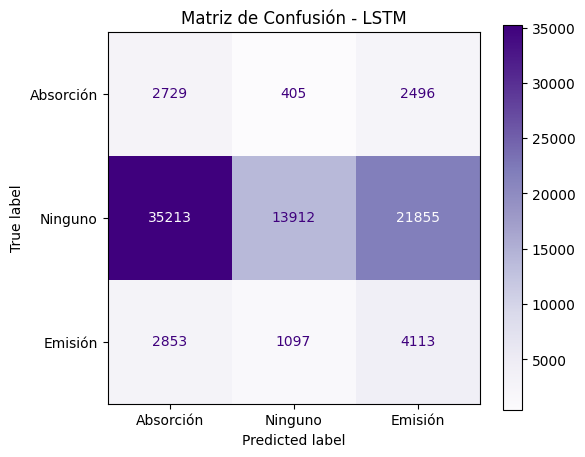

In [34]:
mejor_modelo_LSTM = load_model('mejor_modelo_LSTM.h5')

y_pred = mejor_modelo_LSTM.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absorción', 'Ninguno', 'Emisión'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusión - LSTM")
plt.show() 

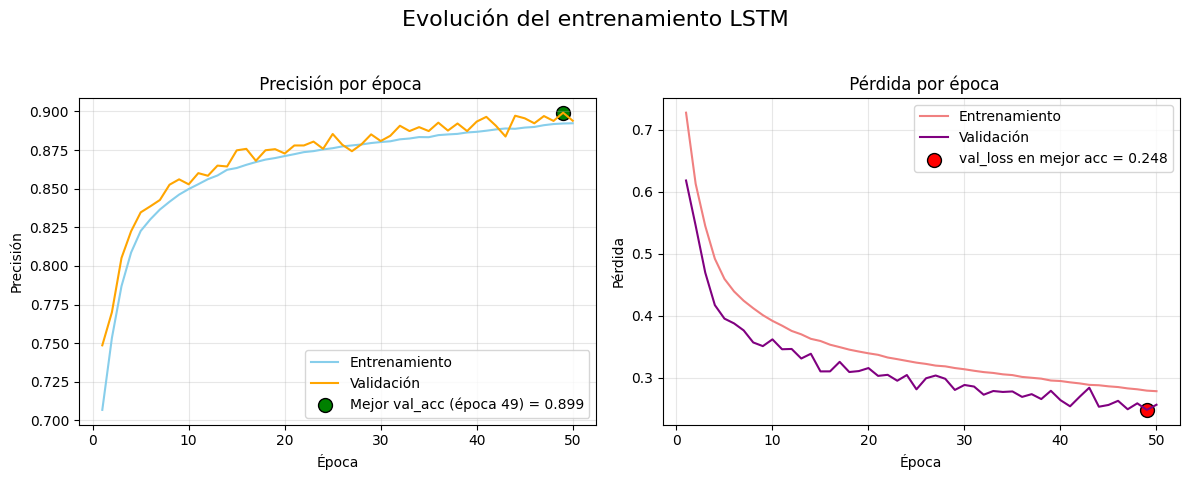

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ajustar mejor época para mostrarla desde 1 ---
mejor_epoca = np.argmax(history_LSTM.history['val_accuracy'])
mejor_epoca_mostrar = mejor_epoca + 1  # para humanos
mejor_acc = history_LSTM.history['val_accuracy'][mejor_epoca]
mejor_loss = history_LSTM.history['val_loss'][mejor_epoca]

# --- Crear vector de épocas desde 1 ---
epocas = np.arange(1, len(history_LSTM.history['val_accuracy']) + 1)

# --- Gráficos ---
plt.figure(figsize=(12, 5))

# 🎯 Precisión
plt.subplot(1, 2, 1)
plt.plot(epocas, history_LSTM.history['accuracy'], label='Entrenamiento', color='skyblue')
plt.plot(epocas, history_LSTM.history['val_accuracy'], label='Validación', color='orange')
plt.scatter(mejor_epoca_mostrar, mejor_acc, color='green', s=100, marker='o', edgecolors='black',
            label=f'Mejor val_acc (época {mejor_epoca_mostrar}) = {mejor_acc:.3f}')
plt.title(' Precisión por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(alpha=0.3)

# 📉 Pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, history_LSTM.history['loss'], label='Entrenamiento', color='lightcoral')
plt.plot(epocas, history_LSTM.history['val_loss'], label='Validación', color='purple')
plt.scatter(mejor_epoca_mostrar, mejor_loss, color='red', s=100, marker='o', edgecolors='black',
            label=f'val_loss en mejor acc = {mejor_loss:.3f}')
plt.title(' Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle("Evolución del entrenamiento LSTM", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Epoch 1/50
2592/2593 [============================>.] - ETA: 0s - loss: 0.2828 - accuracy: 0.9059
Epoch 1: val_accuracy improved from -inf to 0.91388, saving model to mejor_modelo_R.h5
2593/2593 [==============================] - 86s 33ms/step - loss: 0.2828 - accuracy: 0.9059 - val_loss: 0.2449 - val_accuracy: 0.9139
Epoch 2/50
2592/2593 [============================>.] - ETA: 0s - loss: 0.2741 - accuracy: 0.9087
Epoch 2: val_accuracy improved from 0.91388 to 0.92175, saving model to mejor_modelo_R.h5
2593/2593 [==============================] - 85s 33ms/step - loss: 0.2740 - accuracy: 0.9087 - val_loss: 0.2297 - val_accuracy: 0.9218
Epoch 3/50
2592/2593 [============================>.] - ETA: 0s - loss: 0.2664 - accuracy: 0.9109
Epoch 3: val_accuracy did not improve from 0.92175
2593/2593 [==============================] - 87s 33ms/step - loss: 0.2664 - accuracy: 0.9108 - val_loss: 0.2371 - val_accuracy: 0.9175
Epoch 4/50
2592/2593 [============================>.] - ETA: 0s - loss: 0

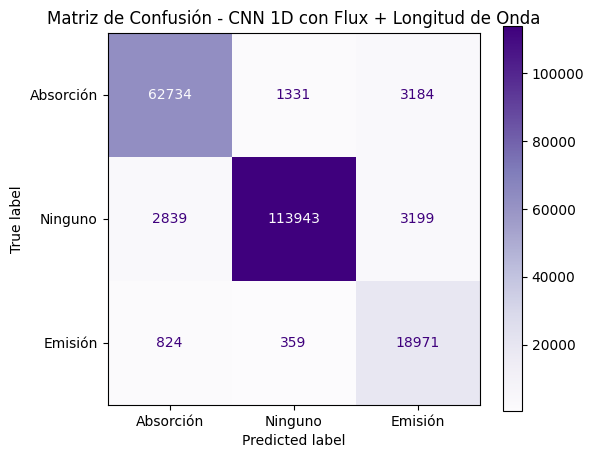

In [ ]:
from tensorflow.keras.optimizers import Adam
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_R.h5',       # Archivo a guardar
    monitor='val_accuracy',           # Puedes usar 'val_loss' también
    save_best_only=True,              # Solo guarda si mejora
    save_weights_only=False,          # Guarda arquitectura + pesos
    verbose=1                         # Imprime cuando guarda
)


history_R = modelo_robusto.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint]            # Agregado aquí
)

# se demoro 75 min y 0.5 seg, acc val 0.94152

In [41]:
mejor_modelo_R = load_model('mejor_modelo_R.h5')

y_pred = mejor_modelo_R.predict(X)
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absorción', 'Ninguno', 'Emisión'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusión - CNN 1D + LSTM")
plt.show() # preciision de 0.942

15724/15724 [==============================] - 106s 7ms/step


ValueError: Found input variables with inconsistent numbers of samples: [100632, 503160]

15724/15724 [==============================] - 99s 6ms/step


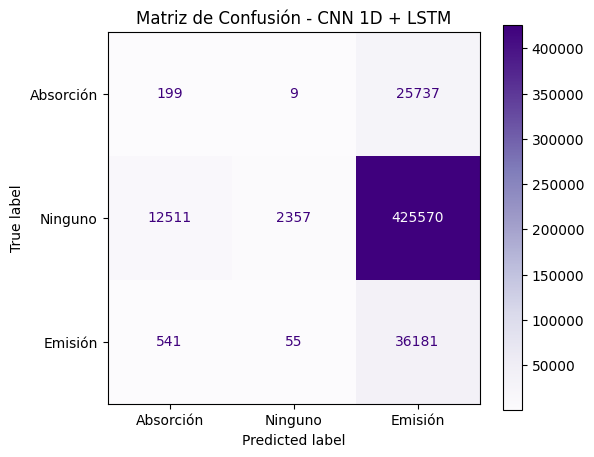

In [ ]:
y_pred

15724/15724 [==============================] - 102s 6ms/step


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (3).

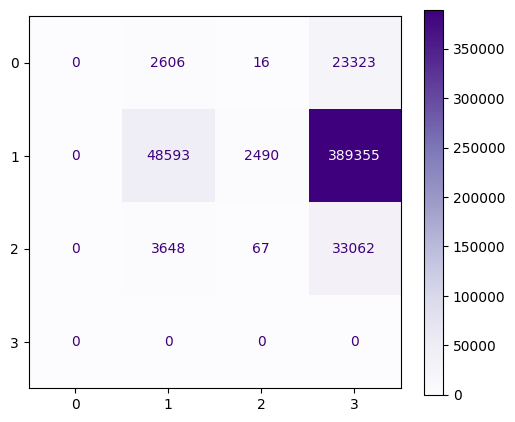

In [40]:
# --- 1. Cargar modelo entrenado ---
mejor_modelo_R = load_model('mejor_modelo_R.h5')

# --- 2. Predecir sobre el conjunto completo ---
y_pred = mejor_modelo_R.predict(X)

# --- 3. Obtener etiquetas predichas (posición del valor máximo) ---
y_pred_labels = np.argmax(y_pred, axis=1)

# --- 4. Verificar si y ya está en formato de etiquetas (no one-hot) ---
if y.ndim == 1:
    y_true = y  # ya está en formato correcto
else:
    y_true = np.argmax(y, axis=1)

# --- 5. Matriz de confusión ---
cm = confusion_matrix(y_true, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absorción', 'Nada', 'Emisión'])

# --- 6. Mostrar gráfico ---
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusión - Mejor modelo R")
plt.tight_layout()
plt.show()


In [36]:
y_mod

array([1, 1, 2, ..., 1, 1, 1])

In [34]:
y

array([0, 0, 1, ..., 0, 0, 0])

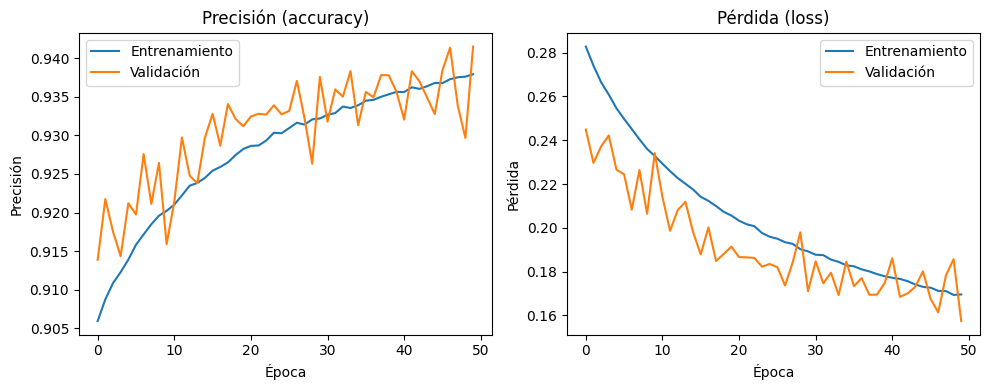

In [15]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_R.history['accuracy'], label='Entrenamiento')
plt.plot(history_R.history['val_accuracy'], label='Validación')
plt.title('Precisión (accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_R.history['loss'], label='Entrenamiento')
plt.plot(history_R.history['val_loss'], label='Validación')
plt.title('Pérdida (loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

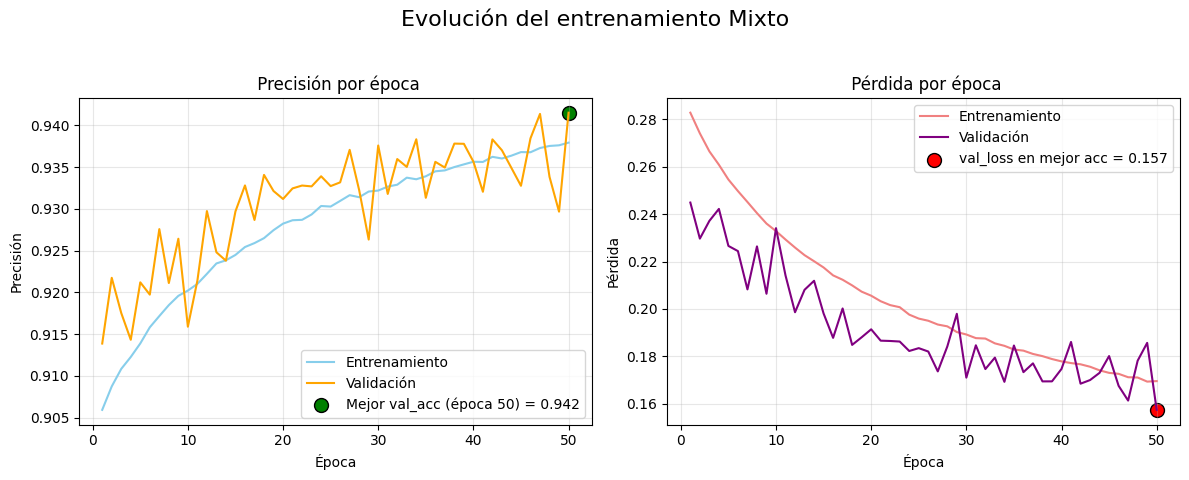

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ajustar mejor época para mostrarla desde 1 ---
mejor_epoca = np.argmax(history_R.history['val_accuracy'])
mejor_epoca_mostrar = mejor_epoca + 1  # para humanos
mejor_acc = history_R.history['val_accuracy'][mejor_epoca]
mejor_loss = history_R.history['val_loss'][mejor_epoca]

# --- Crear vector de épocas desde 1 ---
epocas = np.arange(1, len(history_R.history['val_accuracy']) + 1)

# --- Gráficos ---
plt.figure(figsize=(12, 5))

# 🎯 Precisión
plt.subplot(1, 2, 1)
plt.plot(epocas, history_R.history['accuracy'], label='Entrenamiento', color='skyblue')
plt.plot(epocas, history_R.history['val_accuracy'], label='Validación', color='orange')
plt.scatter(mejor_epoca_mostrar, mejor_acc, color='green', s=100, marker='o', edgecolors='black',
            label=f'Mejor val_acc (época {mejor_epoca_mostrar}) = {mejor_acc:.3f}')
plt.title(' Precisión por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(alpha=0.3)

# 📉 Pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, history_R.history['loss'], label='Entrenamiento', color='lightcoral')
plt.plot(epocas, history_R.history['val_loss'], label='Validación', color='purple')
plt.scatter(mejor_epoca_mostrar, mejor_loss, color='red', s=100, marker='o', edgecolors='black',
            label=f'val_loss en mejor acc = {mejor_loss:.3f}')
plt.title(' Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle("Evolución del entrenamiento Mixto", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [26]:
len(history_R.history['val_accuracy'])


50

Epoch 1/50
2593/2593 [==============================] - ETA: 0s - loss: 1.2108 - accuracy: 0.7414
Epoch 1: val_accuracy improved from -inf to 0.79285, saving model to mejor_modelo.h5
2593/2593 [==============================] - 70s 26ms/step - loss: 1.2108 - accuracy: 0.7414 - val_loss: 1.0118 - val_accuracy: 0.7929
Epoch 2/50
2592/2593 [============================>.] - ETA: 0s - loss: 1.0366 - accuracy: 0.8086
Epoch 2: val_accuracy improved from 0.79285 to 0.84069, saving model to mejor_modelo.h5
2593/2593 [==============================] - 67s 26ms/step - loss: 1.0366 - accuracy: 0.8086 - val_loss: 0.8932 - val_accuracy: 0.8407
Epoch 3/50
2593/2593 [==============================] - ETA: 0s - loss: 0.9749 - accuracy: 0.8254
Epoch 3: val_accuracy did not improve from 0.84069
2593/2593 [==============================] - 65s 25ms/step - loss: 0.9749 - accuracy: 0.8254 - val_loss: 0.8833 - val_accuracy: 0.8401
Epoch 4/50
2591/2593 [============================>.] - ETA: 0s - loss: 0.930

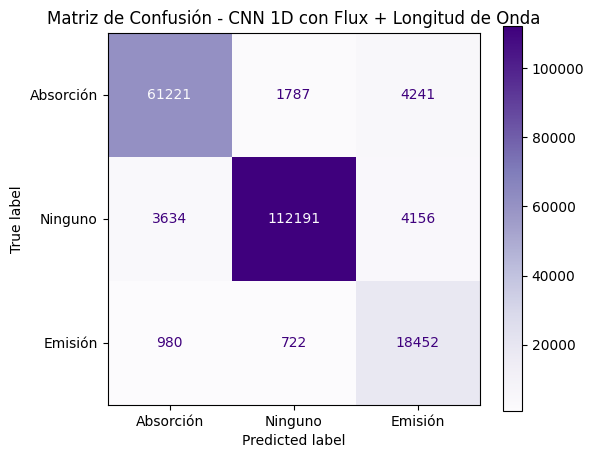

In [ ]:
# --- 6. Entrenar modelo con pesos de clase ---
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo.h5',       # Archivo a guardar
    monitor='val_accuracy',           # Puedes usar 'val_loss' también
    save_best_only=True,              # Solo guarda si mejora
    save_weights_only=False,          # Guarda arquitectura + pesos
    verbose=1                         # Imprime cuando guarda
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[checkpoint]            # Agregado aquí
)

# --- 7. Evaluación ---
mejor_modelo = load_model('mejor_modelo.h5')


y_pred = mejor_modelo.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absorción', 'Ninguno', 'Emisión'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusión - CNN 1D con Flux + Longitud de Onda")
plt.show()   #se demoro 62m y 9.9s

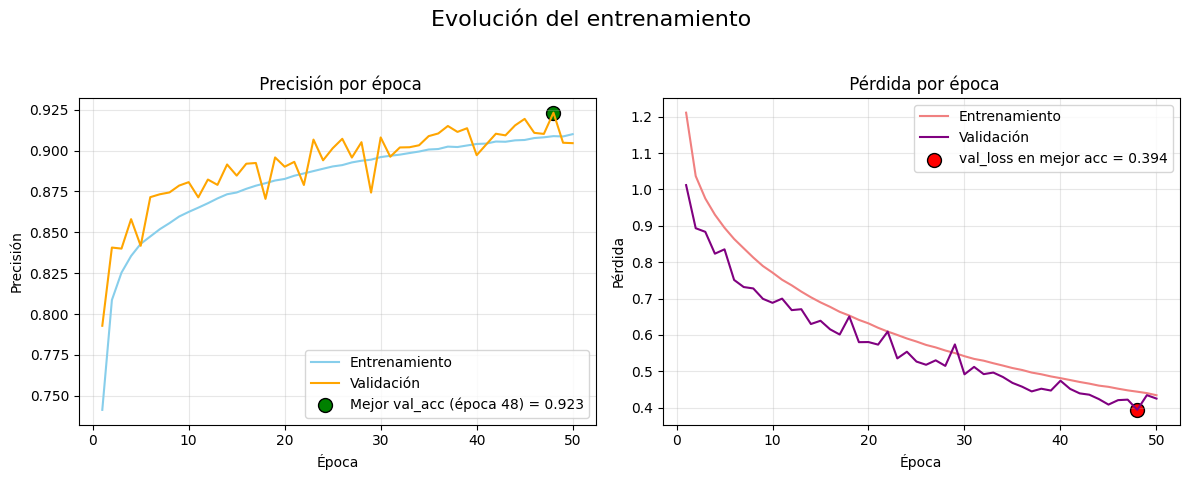

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# --- Ajustar mejor época para mostrarla desde 1 ---
mejor_epoca = np.argmax(history.history['val_accuracy'])
mejor_epoca_mostrar = mejor_epoca + 1  # para humanos
mejor_acc = history.history['val_accuracy'][mejor_epoca]
mejor_loss = history.history['val_loss'][mejor_epoca]

# --- Crear vector de épocas desde 1 ---
epocas = np.arange(1, len(history.history['val_accuracy']) + 1)

# --- Gráficos ---
plt.figure(figsize=(12, 5))

# 🎯 Precisión
plt.subplot(1, 2, 1)
plt.plot(epocas, history.history['accuracy'], label='Entrenamiento', color='skyblue')
plt.plot(epocas, history.history['val_accuracy'], label='Validación', color='orange')
plt.scatter(mejor_epoca_mostrar, mejor_acc, color='green', s=100, marker='o', edgecolors='black',
            label=f'Mejor val_acc (época {mejor_epoca_mostrar}) = {mejor_acc:.3f}')
plt.title(' Precisión por época')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(alpha=0.3)

# 📉 Pérdida
plt.subplot(1, 2, 2)
plt.plot(epocas, history.history['loss'], label='Entrenamiento', color='lightcoral')
plt.plot(epocas, history.history['val_loss'], label='Validación', color='purple')
plt.scatter(mejor_epoca_mostrar, mejor_loss, color='red', s=100, marker='o', edgecolors='black',
            label=f'val_loss en mejor acc = {mejor_loss:.3f}')
plt.title(' Pérdida por época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle("Evolución del entrenamiento ", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Crear figura con fondo negro
plt.figure(figsize=(10, 4), facecolor='black')

# Accuracy
plt.subplot(1, 2, 1, facecolor='black')
plt.plot(history.history['accuracy'], label='Entrenamiento', color='lime')
plt.plot(history.history['val_accuracy'], label='Validación', color='deepskyblue')
plt.title('Precisión (accuracy)', color='white')
plt.xlabel('Época', color='white')
plt.ylabel('Precisión', color='white')
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.tick_params(colors='white')

# Loss
plt.subplot(1, 2, 2, facecolor='black')
plt.plot(history.history['loss'], label='Entrenamiento', color='orange')
plt.plot(history.history['val_loss'], label='Validación', color='magenta')
plt.title('Pérdida (loss)', color='white')
plt.xlabel('Época', color='white')
plt.ylabel('Pérdida', color='white')
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.tick_params(colors='white')

# Ajustar diseño final
plt.tight_layout()
plt.show()


In [ ]:
print("X_test shape:", X_test.shape)
print("Input shape esperada por el modelo:", model.input_shape)


In [ ]:
import tensorflow as tf

with tf.device('/CPU:0'):
    y_pred = model.predict(X_test, batch_size=256)


In [ ]:
print(X_test[0])

In [ ]:
y_test

In [ ]:
print("NaNs en X_test:", np.isnan(X_test).sum())
print("Infs en X_test:", np.isinf(X_test).sum())


In [ ]:
print("Min:", np.min(X_train))
print("Max:", np.max(X_train))
print("Mean:", np.mean(X_train))
print("Std:", np.std(X_train))


In [ ]:
X_train

In [ ]:
print("Total NaNs:", np.isnan(X_train).sum())


In [ ]:
nan_indices = np.argwhere(np.isnan(X_train))
print("Indices con NaN:", nan_indices[:10])  # muestra los primeros 10


In [ ]:
mask = ~np.isnan(X_train).any(axis=(1, 2))
X_train = X_train[mask]
y_train = y_train[mask]


In [ ]:
mask_test = ~np.isnan(X_test).any(axis=(1, 2))
X_test = X_test[mask_test]
y_test = y_test[mask_test]


In [ ]:
print("NaNs en X_train:", np.isnan(X_train).sum())
print("NaNs en X_test:", np.isnan(X_test).sum())


6481/6481 [==============================] - 19s 3ms/step


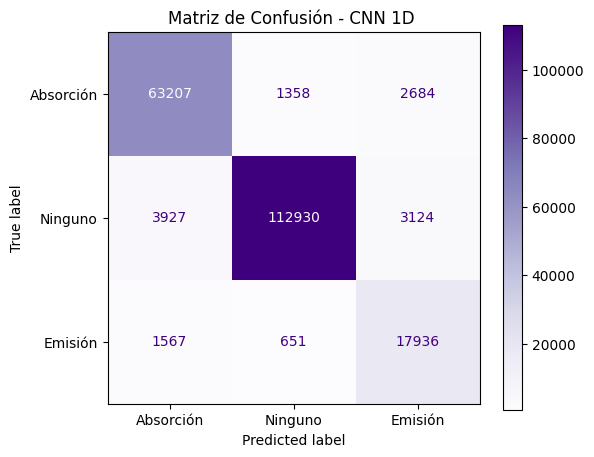

In [7]:
from tensorflow.keras.models import load_model

mejor_modelo = load_model('mejor_modelo.h5')

# Usarlo directamente:
y_pred = mejor_modelo.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Absorción', 'Ninguno', 'Emisión'])

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(cmap="Purples", ax=ax, values_format='d')
plt.title("Matriz de Confusión - CNN 1D ")
plt.show()